# PROBLEM STATEMENT


- You own an ice cream business and you would like to create a model that could predict the daily revenue in dollars based on the outside air temperature (degC). You decided to build a simple Artificial Neural Network to solve this problem.  

- Data set:
  - Input (X): Outside Air Temperature
  - Output (Y): Overall daily revenue generated in dollars

- This example is a regression example, we will cover regression in more details in future projects.


<table>
  <tr><td>
    <img src="https://upload.wikimedia.org/wikipedia/commons/6/63/Big_Gay_Ice_Cream_Truck.jpg"
          width="400">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1. Predict Ice Cream Sales [Source: https://upload.wikimedia.org/wikipedia/commons/6/63/Big_Gay_Ice_Cream_Truck.jpg]
  </td></tr>
</table>


# STEP #0: IMPORT LIBRARIES

In [1]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prevent TensorFlow from reserving most GPU memory upfront

gpu = tf.config.experimental.list_physical_devices('GPU')
if gpu:
    try:
        tf.config.experimental.set_memory_growth(gpu[0], True)
    except RuntimeError as e:
        print(e)
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", gpu)

I0000 00:00:1773594883.162089  645811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773594883.200028  645811 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773594883.887969  645811 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
Built with CUDA: True
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1773594885.215347  645811 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


# STEP #1: IMPORT DATASET

In [2]:
# import CSV file entitled "SalesData.csv"
sales_data = pd.read_csv("../data/SalesData.csv")
sales_data.reset_index(drop=True, inplace=True)

In [3]:
sales_data.head(5)

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


In [4]:
sales_data.tail(5)

,Temperature,Revenue
495,22.274899,524.746364
496,32.893092,755.818399
497,12.588157,306.090719
498,22.362402,566.217304
499,28.957736,655.660388


In [5]:
sales_data.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [6]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


# STEP #2: VISUALIZE DATASET

Text(0.5, 1.0, 'Advertising vs Revenue')

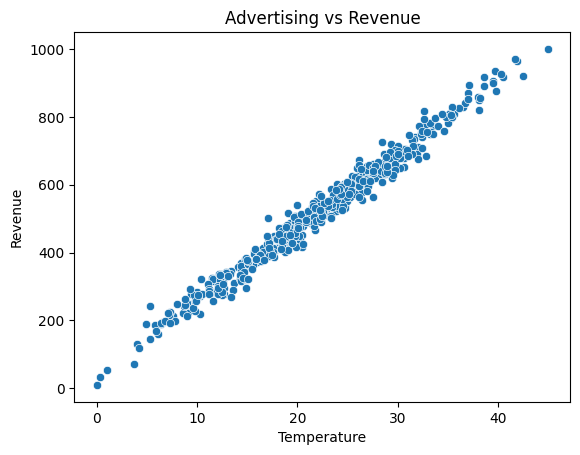

In [7]:
sales_data.keys()
sns.scatterplot(x="Temperature", y="Revenue", data=sales_data)
plt.title("Advertising vs Revenue")

# STEP #3: CREATE TESTING AND TRAINING DATASET

In [8]:

X_train = tf.convert_to_tensor(sales_data[["Temperature"]].to_numpy(dtype="float32"))
y_train = tf.convert_to_tensor(sales_data[["Revenue"]].to_numpy(dtype="float32"))

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)

W0000 00:00:1773594885.347897  645811 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


X_train shape: (500, 1) dtype: <dtype: 'float32'>
y_train shape: (500, 1) dtype: <dtype: 'float32'>


I0000 00:00:1773594885.578978  645811 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


# STEP#4: BUILD AND TRAIN THE MODEL

In [9]:
model = tf.keras.Sequential(
    [tf.keras.layers.Input(shape=(1,)), tf.keras.layers.Dense(units=20)]
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            40 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss=tf.keras.losses.MeanSquaredError())

In [34]:
with tf.device("/GPU:0"):
    epochs_history = model.fit(X_train, y_train, epochs=200, verbose=0)
    print("Training finished.")
    print("Learned weight:", model.layers[0].get_weights()[0][0][0])
    print("Learned bias:", model.layers[0].get_weights()[1][0])
    print("Initial loss:", float(epochs_history.history["loss"][0]))
    print("Final loss:", float(epochs_history.history["loss"][-1]))

Training finished.
Learned weight: 21.358387
Learned bias: 44.79905
Initial loss: 626.63134765625
Final loss: 624.7181396484375


# STEP#5: EVALUATE THE MODEL

In [35]:
epochs_history.history.keys()

dict_keys(['loss'])

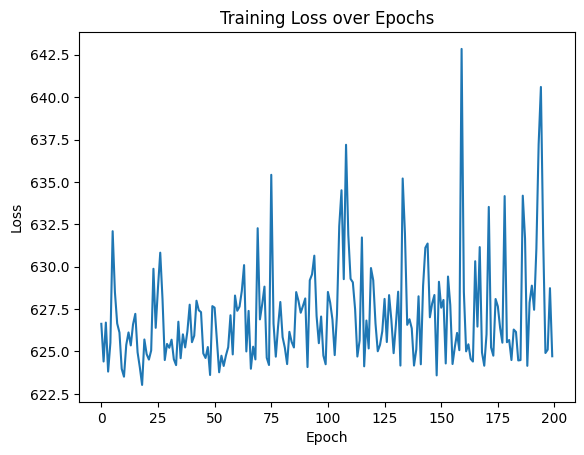

In [36]:
plt.plot(epochs_history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

In [37]:
model.get_weights()

[array([[21.358387, 21.357912, 21.358397, 21.358065, 21.358032, 21.357967,
         21.35792 , 21.357765, 21.358257, 21.358088, 21.358341, 21.358335,
         21.358025, 21.358347, 21.35828 , 21.358053, 21.35814 , 21.357887,
         21.35817 , 21.358192]], dtype=float32),
 array([44.79905 , 44.79916 , 44.799053, 44.79911 , 44.799164, 44.799156,
        44.799156, 44.799152, 44.79908 , 44.799076, 44.799065, 44.79904 ,
        44.799103, 44.79906 , 44.79907 , 44.799114, 44.799137, 44.79912 ,
        44.799088, 44.799076], dtype=float32)]

In [38]:
# Use the trained model to perform predictions



16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


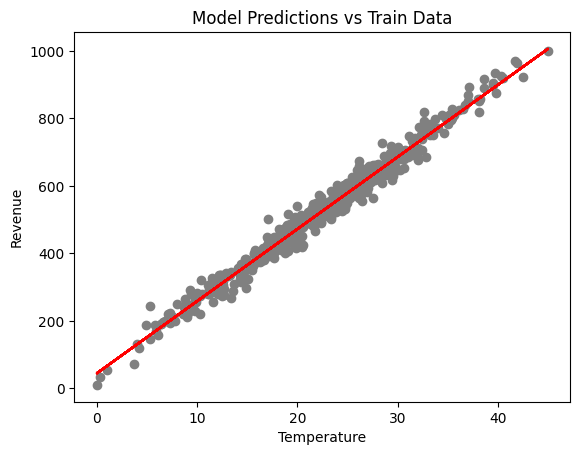

In [39]:
plt.scatter(X_train, y_train, label="Train Data", color="Gray")
plt.plot(X_train, model.predict(X_train), label="Model Predictions", color="Red")
plt.ylabel("Revenue")
plt.xlabel("Temperature")
plt.title("Model Predictions vs Train Data")
plt.show()

# STEP #6 (OPTIONAL): CONFIRM USING REGRESSION KIT IN SCIKIT LEARN!

In [40]:
X_train = sales_data[["Temperature"]].values.reshape(-1, 1)
X_train.shape

(500, 1)

In [41]:
y_train = sales_data[["Revenue"]].values.reshape(-1, 1)
y_train.shape

(500, 1)

In [42]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression(fit_intercept=True)
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
print("Linear model coefficients:", regressor.coef_)
print("Linear model intercept:", regressor.intercept_)

Linear model coefficients: [[21.44362551]]
Linear model intercept: [44.83126709]


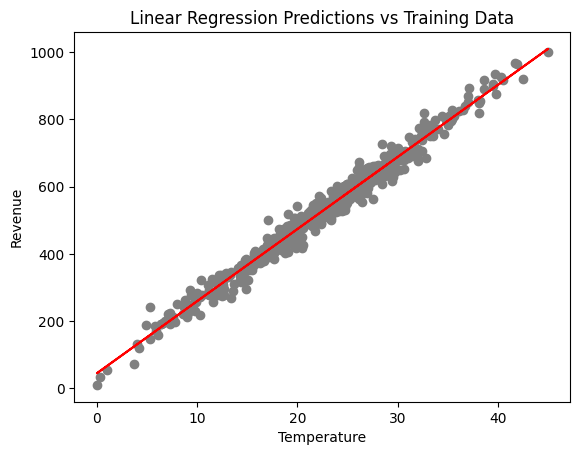

In [44]:
plt.scatter(X_train, y_train, color="gray")
plt.plot(X_train, regressor.predict(X_train), color="red")
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.title("Linear Regression Predictions vs Training Data")
plt.show()

# EXCELLENT JOB & CONGRATULATIONS! NOW YOU HAVE BUILT YOUR SECOND NEURAL NETWORK MODEL USING TENSORFLOW 2.0 IN GOOGLE COLAB!